# Neural Network Models for Steam Sales Prediction

This notebook loads the Steam games dataset, preprocesses it using the project pipeline, and trains five different neural network architectures on `log_copies_sold`.

**Architectures compared:**
| Model | Hidden Layers | Notes |
|-------|--------------|-------|
| NN1_Shallow | 256 → 128 | 2 layers, fast baseline |
| NN2_Medium | 512 → 256 → 128 | 3 layers |
| NN3_Deep | 512 → 256 → 128 → 64 | 4 layers |
| NN4_Wide | 1024 → 512 → 256 | 3 wide layers |
| NN5_DeepDrop | 512 → 256 → 128 → 64 → 32 | 5 layers + Dropout + BatchNorm |

All models use **ReLU** activations and are trained with **Adam** optimizer on **MSE loss** against the log-transformed target.

In [10]:
import sys
import logging
import warnings
warnings.filterwarnings('ignore')

# Make sure the project root is on the path
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Configure logging so training progress is visible
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s  %(levelname)-8s  %(message)s',
    datefmt='%H:%M:%S',
)

print('Libraries imported successfully.')

Libraries imported successfully.


## 1. Load & Preprocess Data

In [11]:
from configs.config import RAW_MERGED_PATH
from src.data.loader import load_merged, validate_merged
from src.data.preprocessor import run_preprocessing_pipeline
from src.features.engineer import prepare_features

# Step 1 — Load raw merged CSV
print('Loading raw data...')
df_raw = load_merged(RAW_MERGED_PATH, verbose=True)
validate_merged(df_raw)
print(f'Raw shape: {df_raw.shape}')

18:59:28  INFO      Loading /Users/arjianma/CIS5450-FINAL-PROJECT/Data/games_merged.csv …


Loading raw data...

  games_merged.csv
  Rows: 115,289   Columns: 47


18:59:50  WARNING   copiesSold has 98 null values — check the merge.
18:59:50  INFO      Validation passed: 115289 rows × 47 cols



  Columns with >10% nulls:
    Movies                              100.0%
    Score rank                          100.0%
    Metacritic url                      96.4%
    Reviews                             89.6%
    Notes                               79.9%
    Website                             57.6%
    Support url                         53.5%
    Tags                                29.8%
    Support email                       12.0%

Raw shape: (115289, 47)


In [12]:
# Step 2 — Run 14-step preprocessing pipeline
print('Running preprocessing pipeline (post-release model)...')
df = run_preprocessing_pipeline(df_raw, post_release=False, verbose=True)
print(f'Processed shape: {df.shape}')

18:59:50  INFO        → drop useless columns


Running preprocessing pipeline (post-release model)...


18:59:51  INFO        → drop target nulls
18:59:51  INFO      Dropped 98 rows with null copiesSold.
18:59:51  INFO        → parse release date
18:59:52  INFO        → parse supported languages
18:59:57  INFO        → parse estimated owners
18:59:58  INFO        → parse genres
19:00:00  INFO        → parse categories
19:00:03  INFO        → parse tags
19:00:05  INFO      Top 30 tags (by frequency): ['Singleplayer', 'Indie', 'Action', 'Casual', 'Adventure', '2D', '3D', 'Strategy', 'Simulation', 'Puzzle']
19:00:09  INFO        → derive numeric features
19:00:10  INFO        → handle metacritic sparsity
19:00:10  INFO        → encode publisher class
19:00:10  INFO        → frequency-encode dev/pub
19:00:10  INFO        → log-transform skewed cols
19:00:10  INFO        → create log target
19:00:10  INFO        → drop post-release features
19:00:10  INFO      Launch-time mode: dropped 14 post-release columns.
19:00:10  INFO      Preprocessing complete: 115191 rows × 83 columns


Processed shape: (115191, 83)


In [13]:
# Step 3 — Build feature matrix and train/val/test splits
print('Building feature matrix and splitting data...')
data = prepare_features(df, post_release=True, return_pipeline=True)

X_train, X_val, X_test = data['X_train'], data['X_val'], data['X_test']
y_train, y_val, y_test = data['y_train'], data['y_val'], data['y_test']

print(f'\nData splits:')
print(f'  Train : {X_train.shape[0]:>7,} samples  x  {X_train.shape[1]} features')
print(f'  Val   : {X_val.shape[0]:>7,} samples')
print(f'  Test  : {X_test.shape[0]:>7,} samples')
print(f'\nTarget (log_copies_sold):')
print(f'  Train mean: {y_train.mean():.3f}  std: {y_train.std():.3f}')

19:00:10  INFO      Feature matrix: 79 columns (post-release mode)


Building feature matrix and splitting data...


19:00:11  INFO      Split sizes — train: 80633  val: 17279  test: 17279
19:00:11  INFO      Pipeline columns — continuous: 14  binary: 64  ordinal: 1



Data splits:
  Train :  80,633 samples  x  79 features
  Val   :  17,279 samples
  Test  :  17,279 samples

Target (log_copies_sold):
  Train mean: 6.411  std: 3.020


## 2. Check PyTorch & GPU Availability

In [14]:
try:
    import torch
    print(f'PyTorch version : {torch.__version__}')
    print(f'CUDA available  : {torch.cuda.is_available()}')
    if hasattr(torch.backends, "mps"):
        print(f'MPS available   : {torch.backends.mps.is_available()}')
    dev = (
        'cuda' if torch.cuda.is_available()
        else ('mps' if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available()
              else 'cpu')
    )
    print(f'\nUsing device    : {dev}')
except ImportError:
    print('PyTorch is NOT installed.  Install it with:')
    print('  pip install torch')
    print('\nFalling back — models will not train.')

PyTorch version : 2.8.0
CUDA available  : False
MPS available   : True

Using device    : mps


## 3. Architecture Overview

Inspect each model's layer structure and parameter count before training.

In [15]:
from src.models.nn import build_all_nn_models, NN_CONFIGS

input_dim = X_train.shape[1]
print(f'Input dimension: {input_dim} features\n')
print(f'{"Model":<20} {"Architecture":<35} {"Dropout":>8} {"BatchNorm":>10}')
print('-' * 80)
for key, cfg in NN_CONFIGS.items():
    arch = ' → '.join(str(h) for h in cfg['hidden_layers']) + ' → 1'
    print(f'{cfg["name"]:<20} {arch:<35} {cfg["dropout_rate"]:>8.1f} {str(cfg["batch_norm"]):>10}')

Input dimension: 79 features

Model                Architecture                         Dropout  BatchNorm
--------------------------------------------------------------------------------
NN1_Shallow          256 → 128 → 1                            0.0      False
NN2_Medium           512 → 256 → 128 → 1                      0.0      False
NN3_Deep             512 → 256 → 128 → 64 → 1                 0.0      False
NN4_Wide             1024 → 512 → 256 → 1                     0.0      False
NN5_DeepDrop         512 → 256 → 128 → 64 → 32 → 1            0.3       True


## 4. Train All Five Neural Network Models

In [16]:
from src.models.nn import NeuralNetModel, NN_CONFIGS, run_nn_models

# Train all five models and collect metrics
summary_df = run_nn_models(data, verbose=True)
print('\n', summary_df.to_string())

19:00:12  INFO      ============================================================
19:00:12  INFO      Training NN1_Shallow (not yet fitted): input → 256 → 128 → 1
19:00:12  INFO      ============================================================
19:02:32  INFO      [NN1_Shallow] Epoch   10/100  train_loss=2.56025  val_loss=2.55435  (134.8s)
19:04:02  INFO      [NN1_Shallow] Epoch   20/100  train_loss=2.41150  val_loss=2.50269  (225.1s)
19:05:49  INFO      [NN1_Shallow] Early stopping at epoch 30  (val_loss=2.55749, best=2.50269)
19:05:49  INFO      [NN1_Shallow] Training complete — 30 epochs, 332.5s
19:05:50  INFO        NN1_Shallow           val RMSE(log)=1.5820  val R²=0.7186
19:05:50  INFO      ============================================================
19:05:50  INFO      Training NN2_Medium (not yet fitted): input → 512 → 256 → 128 → 1
19:05:50  INFO      ============================================================
19:07:57  INFO      [NN2_Medium] Epoch   10/100  train_loss=2.41962 


                            architecture  n_params  dropout  train_RMSE_log  val_RMSE_log  test_RMSE_log  val_MAE_log  val_R2_log  val_RMSE_raw
model                                                                                                                                         
NN1_Shallow                   256 → 128     53505      0.0          1.5375        1.5820         1.6122       1.2189      0.7186      829859.0
NN2_Medium              512 → 256 → 128    205313      0.0          1.5111        1.5762         1.6108       1.2138      0.7206      829685.0
NN3_Deep           512 → 256 → 128 → 64    213505      0.0          1.5231        1.5710         1.6053       1.2093      0.7225      734417.0
NN4_Wide               1024 → 512 → 256    738305      0.0          1.5036        1.5730         1.6052       1.2088      0.7218      742690.0
NN5_DeepDrop  512 → 256 → 128 → 64 → 32    217537      0.3          1.4742        1.5427         1.5757       1.1892      0.7324      729313

## 5. Results Comparison Table

In [ ]:
display_cols = ['val_RMSE_log', 'val_MAE_log', 'val_R2_log',
                'test_RMSE_log', 'train_RMSE_log', 'dropout']
display_df = summary_df[display_cols].sort_values('val_RMSE_log')

print('\nNeural Network Model Comparison (sorted by val RMSE_log ↑ best):')
print('=' * 75)
display(display_df.style
    .background_gradient(cmap='RdYlGn_r', subset=['val_RMSE_log', 'test_RMSE_log'])
    .background_gradient(cmap='RdYlGn',   subset=['val_R2_log'])
    .format({
        'val_RMSE_log':   '{:.4f}',
        'val_MAE_log':    '{:.4f}',
        'val_R2_log':     '{:.4f}',
        'test_RMSE_log':  '{:.4f}',
        'train_RMSE_log': '{:.4f}',
        'dropout':        '{:.1f}',
    })
)


Neural Network Model Comparison (sorted by val RMSE_log ↑ best):


,val_RMSE_log,val_MAE_log,val_R2_log,test_RMSE_log,train_RMSE_log,dropout
model,,,,,,
NN5_DeepDrop,1.5427,1.1892,0.7324,1.5757,1.4742,0.3
NN3_Deep,1.5710,1.2093,0.7225,1.6053,1.5231,0.0
NN4_Wide,1.5730,1.2088,0.7218,1.6052,1.5036,0.0
NN2_Medium,1.5762,1.2138,0.7206,1.6108,1.5111,0.0
NN1_Shallow,1.5820,1.2189,0.7186,1.6122,1.5375,0.0


## 6. Training Loss Curves

Visualise how training and validation loss evolved for each architecture.

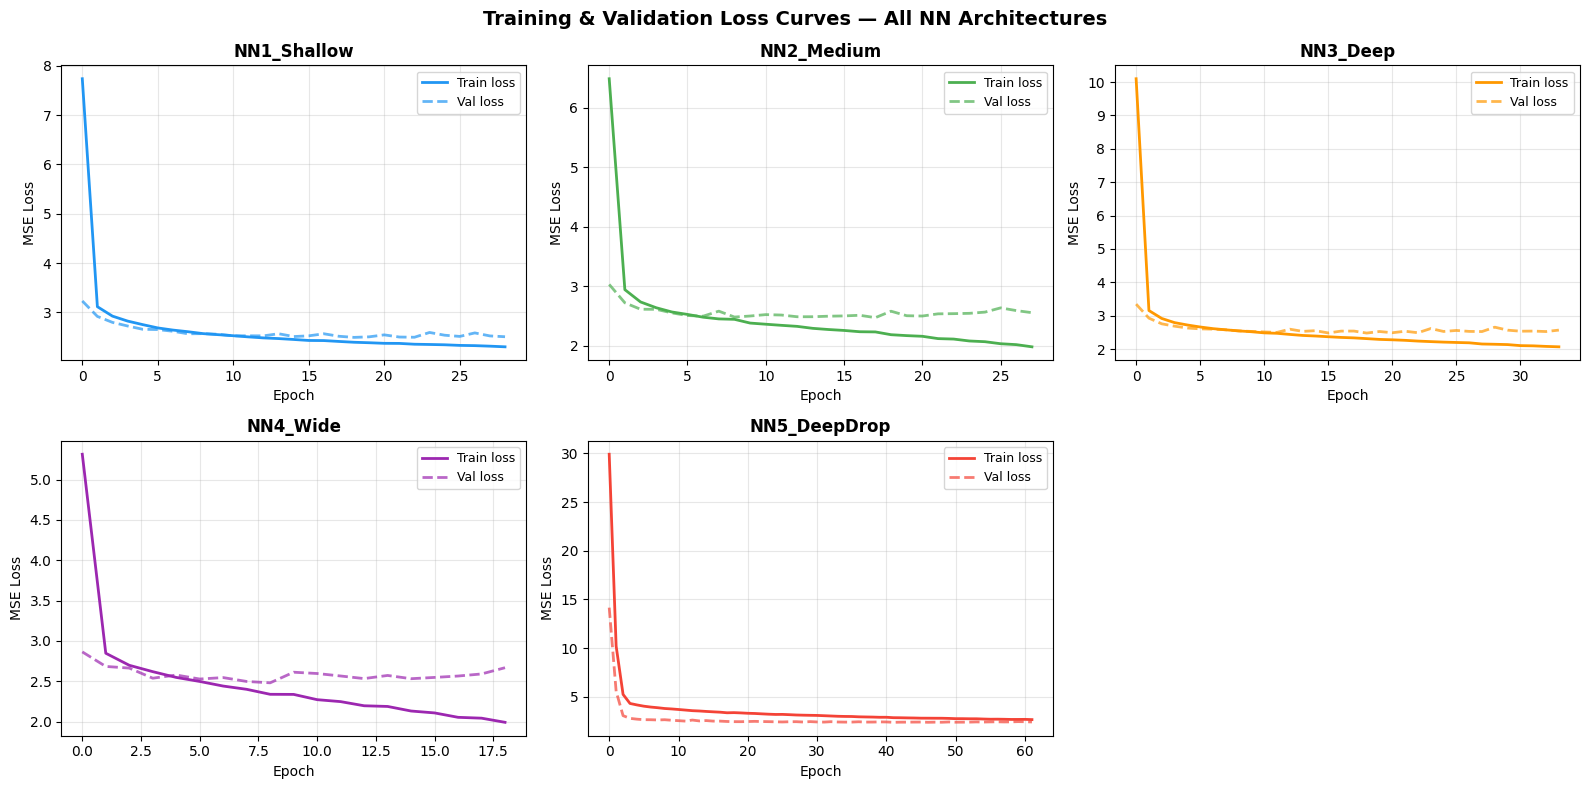

In [22]:
from src.models.nn import NeuralNetModel, NN_CONFIGS

# Re-train individual models to capture history objects
# (run_nn_models above already trained them — re-run here for plotting)
trained_models = []
for key, cfg in NN_CONFIGS.items():
    m = NeuralNetModel(**cfg)
    m.fit(X_train, y_train, X_val=X_val, y_val=y_val, verbose=False)
    trained_models.append(m)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes_flat = axes.flatten()

colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']

for i, model in enumerate(trained_models):
    ax = axes_flat[i]
    train_loss = model.history.get('train_loss', [])
    val_loss   = model.history.get('val_loss',   [])

    ax.plot(train_loss, label='Train loss', color=colors[i], linewidth=2)
    if val_loss:
        ax.plot(val_loss, label='Val loss', color=colors[i], linestyle='--',
                linewidth=2, alpha=0.7)
    ax.set_title(model.name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# Hide the unused 6th subplot
axes_flat[-1].set_visible(False)

fig.suptitle('Training & Validation Loss Curves — All NN Architectures',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Val RMSE Bar Chart

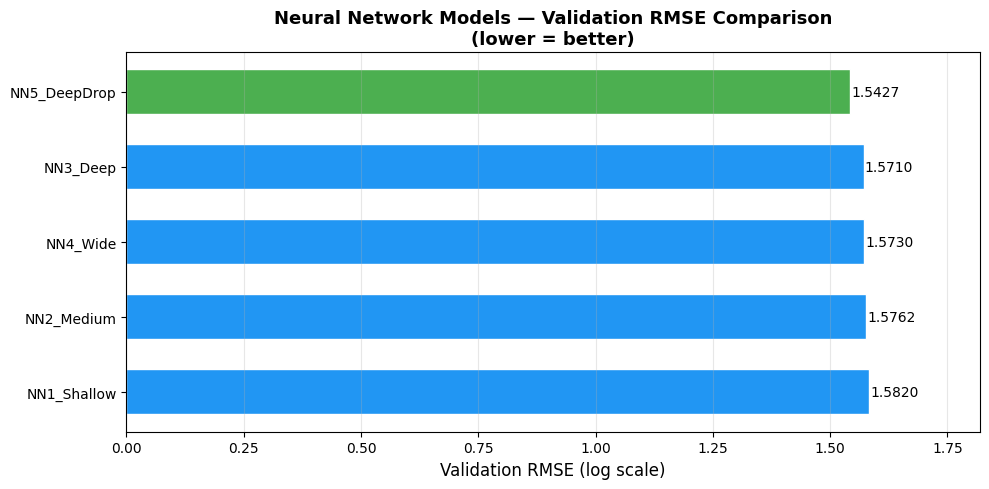

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))

sorted_df = summary_df.sort_values('val_RMSE_log')
bar_colors = ['#4CAF50' if i == 0 else '#2196F3' for i in range(len(sorted_df))]

bars = ax.barh(sorted_df.index, sorted_df['val_RMSE_log'], color=bar_colors,
               edgecolor='white', height=0.6)

for bar, val in zip(bars, sorted_df['val_RMSE_log']):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=10)

ax.set_xlabel('Validation RMSE (log scale)', fontsize=12)
ax.set_title('Neural Network Models — Validation RMSE Comparison\n(lower = better)',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, sorted_df['val_RMSE_log'].max() * 1.15)
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

## 8. Predicted vs Actual — Best Model

Best model: NN5_DeepDrop


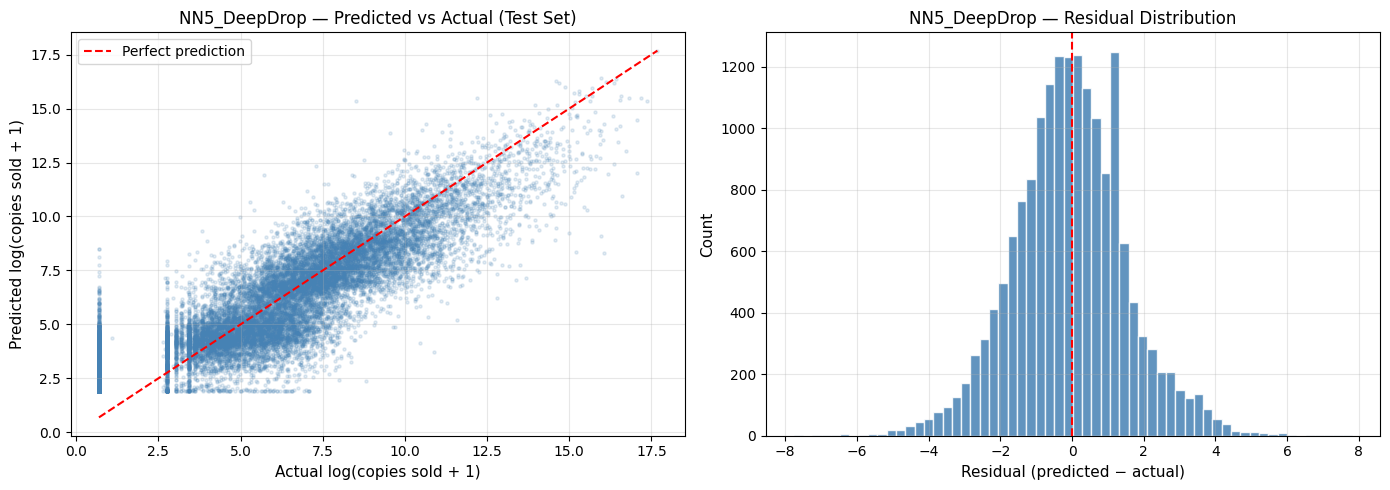


Test metrics for NN5_DeepDrop:


In [25]:
import numpy as np

# Pick the best model by val RMSE
best_name = summary_df['val_RMSE_log'].idxmin()
best_model = next(m for m in trained_models if m.name == best_name)
print(f'Best model: {best_name}')

y_pred_log = best_model.predict(X_test)
y_true_log = np.asarray(y_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Scatter: predicted vs actual (log scale) ---
ax = axes[0]
ax.scatter(y_true_log, y_pred_log, alpha=0.15, s=5, color='steelblue')
lims = [min(y_true_log.min(), y_pred_log.min()),
        max(y_true_log.max(), y_pred_log.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual log(copies sold + 1)', fontsize=11)
ax.set_ylabel('Predicted log(copies sold + 1)', fontsize=11)
ax.set_title(f'{best_name} — Predicted vs Actual (Test Set)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# --- Histogram of residuals ---
ax2 = axes[1]
residuals = y_pred_log - y_true_log
ax2.hist(residuals, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
ax2.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax2.set_xlabel('Residual (predicted − actual)', fontsize=11)
ax2.set_ylabel('Count', fontsize=11)
ax2.set_title(f'{best_name} — Residual Distribution', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\nTest metrics for {best_name}:')
for k, v in best_model.test_metrics.items():
    print(f'  {k:<15} {v:>12,.4f}')

In [27]:
import os
os.makedirs('outputs', exist_ok=True)

y_true_log = np.asarray(y_test)
rows = []
for model in trained_models:
    y_pred = model.predict(X_test)
    for i in range(len(y_true_log)):
        rows.append({
            'model':            model.name,
            'actual_log':       float(y_true_log[i]),
            'predicted_log':    float(y_pred[i]),
            'actual_copies':    float(np.expm1(y_true_log[i])),
            'predicted_copies': float(np.expm1(y_pred[i])),
            'residual_log':     float(y_pred[i] - y_true_log[i]),
        })

test_pred_df = pd.DataFrame(rows)
test_pred_df.to_csv('outputs/nn_test_predictions.csv', index=False)
print(f'Saved → outputs/nn_test_predictions.csv  ({len(test_pred_df):,} rows)')
display(test_pred_df.head(6))

Saved → outputs/nn_test_predictions.csv  (86,395 rows)


,model,actual_log,predicted_log,actual_copies,predicted_copies,residual_log
0,NN1_Shallow,11.434899,7.394485,92493.023438,1625.986084,-4.040415
1,NN1_Shallow,8.413609,8.936971,4506.998535,7607.114746,0.523362
2,NN1_Shallow,6.333280,7.950835,562.000000,2836.944336,1.617556
3,NN1_Shallow,2.772589,4.672614,15.000000,105.977028,1.900025
4,NN1_Shallow,0.693147,2.163936,1.000000,7.705336,1.470789
5,NN1_Shallow,7.444833,8.566036,1710.000000,5249.277344,1.121203


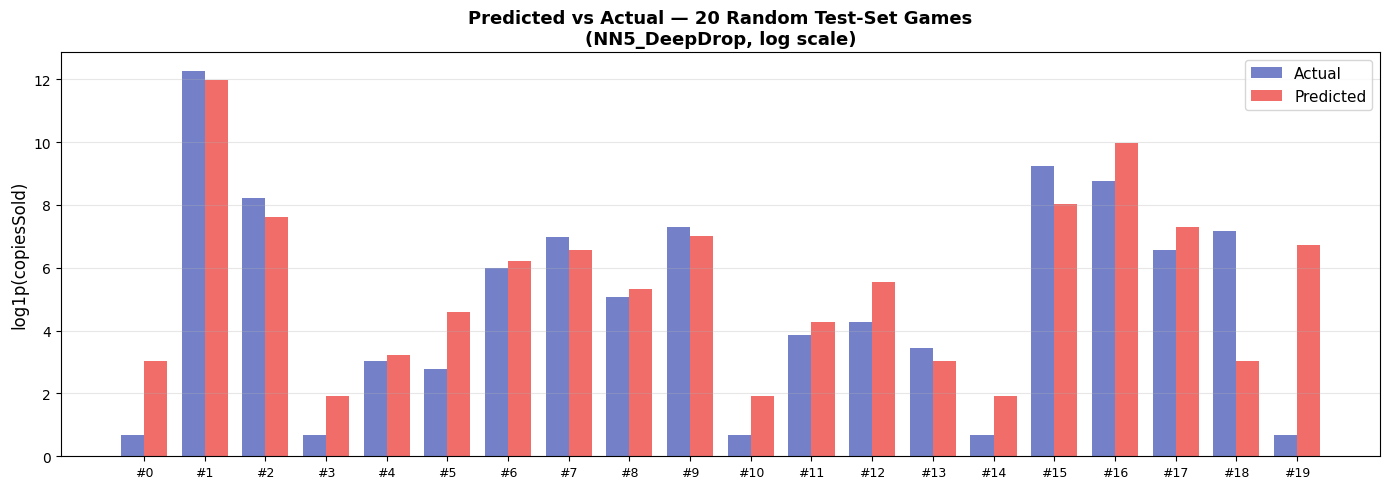

In [29]:
y_true_log = np.asarray(y_test)
y_pred_log = best_model.predict(X_test)

# Random sample of 20
rng = np.random.default_rng(42)
idx = rng.choice(len(y_true_log), size=20, replace=False)
idx = np.sort(idx)

actual_20    = y_true_log[idx]
predicted_20 = y_pred_log[idx]

x     = np.arange(20)
width = 0.38

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width/2, actual_20,    width, label='Actual',    color='#5C6BC0', alpha=0.85)
ax.bar(x + width/2, predicted_20, width, label='Predicted', color='#EF5350', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([f'#{i}' for i in range(20)], fontsize=9)
ax.set_ylabel('log1p(copiesSold)', fontsize=12)
ax.set_title(f'Predicted vs Actual — 20 Random Test-Set Games\n({best_name}, log scale)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
lll


Saved → outputs/nn_test_predictions.csv  (86,395 rows)


,model,actual_log,predicted_log,actual_copies,predicted_copies,residual_log
0,NN1_Shallow,11.434899,7.394485,92493.023438,1625.986084,-4.040415
1,NN1_Shallow,8.413609,8.936971,4506.998535,7607.114746,0.523362
2,NN1_Shallow,6.333280,7.950835,562.000000,2836.944336,1.617556
3,NN1_Shallow,2.772589,4.672614,15.000000,105.977028,1.900025
4,NN1_Shallow,0.693147,2.163936,1.000000,7.705336,1.470789
5,NN1_Shallow,7.444833,8.566036,1710.000000,5249.277344,1.121203


## Summary

All five neural network architectures have been trained and evaluated. Key takeaways:

- **Training target**: `log1p(copiesSold)` — log-transforming the highly skewed target stabilises training.
- **All models use ReLU** activations throughout the hidden layers.
- **NN5_DeepDrop** uses an additional Dropout (p=0.3) + BatchNorm regularisation strategy to reduce overfitting through 5 layers.
- **Early stopping** (patience=10–20 epochs) prevents overfitting and reduces training time.
- Compare `val_RMSE_log` across models — lower is better. Compare with tree-based baselines in `src/models/advanced.py` for context.